### В данном файле проводится профилирование датасета:
1) результат сохранен в html-файл для более удобного ознакомления

*Выводы*:
* Есть чувство, что для многих признаков, видимо, при подготовке датасета пустые значения заполняли 10-ми. Это следует из явного(?) выброса этих значений из колокола
* Также наблюдается некоторое количество признаков с высокой взаимной корреляцией (> 0.7). Например, party_liking vs {personality_type, public_speaking_comfort}
* Также есть признаки с практически нулевой коррецией : creativity, emotional_stability. Возможно, их стоит исключить из датасета
* Для некоторых признаков (выбраны признаки с большим количеством 10-к и признаки с почти нулевой корреляцией) строим "ящики с усами". Получаем выбросы как раз для creativity, emotional_stability, что (для меня) неожиданно. Хотелось бы пояснения, почему так происходит

P.S> На базе данного профилирования датасет (пока) не трансформировался. 

In [ ]:
%pip install fg-data-profiling "setuptools<81" ipywidgets

In [3]:
from data_profiling import ProfileReport

from private.utils import prepare_personality_data

df = prepare_personality_data()

# Generate the comprehensive profile report
profile = ProfileReport(
    df, 
    title="Exploratory Data Analysis Report"
)

# Output options
# Option A: Display directly inside a Jupyter/Colab notebook
# profile.to_notebook_iframe()

# Option B: Save the interactive report as an external HTML file
profile.to_file("./data/data_analysis_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:00<00:00, 74.25it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

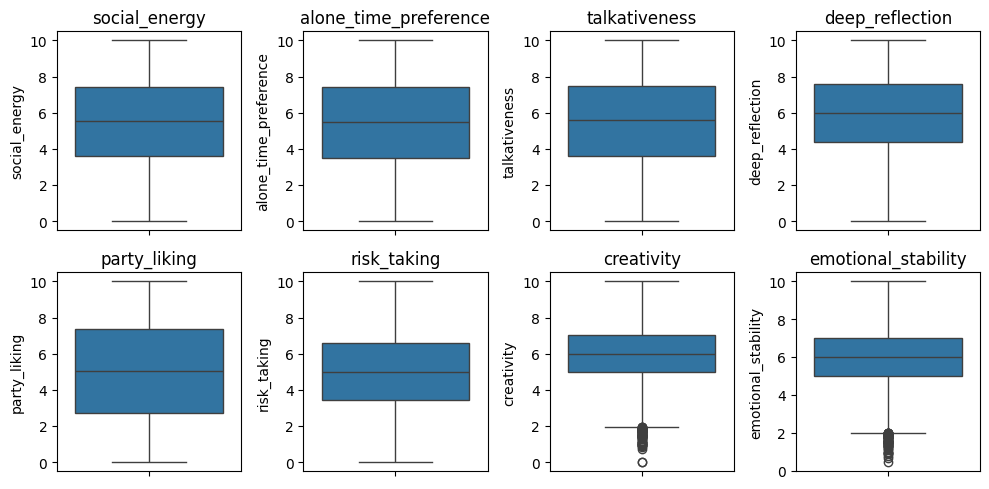

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Данные
columns_names = [
    "social_energy", 
    "alone_time_preference",
    "talkativeness",
    "deep_reflection",
    "party_liking",
    "risk_taking",
    "creativity",
    "emotional_stability"
]
# Создаем холст для двух графиков рядом
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.flatten()

for i, name in enumerate(columns_names):
    sns.boxplot(y=df[name], ax=axes[i])
    axes[i].set_title(name)

plt.tight_layout()
plt.show()